# 🚲 Cyclistic Bike-Share Analysis
### How Do Annual Members and Casual Riders Use Cyclistic Bikes Differently?

**Analyst:** Hammad Muhammad  
**Date:** March 10, 2026  
**Tools Used:** Python, SQL (SQLite), Excel   
**Data Source:** Motivate International Inc. — Divvy Trip Data (March 2025 – February 2026)

---

## 📋 Table of Contents
1. [Phase 1 — Ask](#phase1)
2. [Phase 2 — Prepare](#phase2)
3. [Phase 3 — Process](#phase3)
4. [Phase 4 — Analyze](#phase4)
5. [Phase 5 — Share](#phase5)
6. [Phase 6 — Act](#phase6)

---

<a id='phase1'></a>
## Phase 1: Ask ❓

### Business Task
> Analyze 12 months of Cyclistic trip data to understand how **casual riders** and **annual members** use the service differently, in order to provide data-driven recommendations for a marketing strategy aimed at converting casual riders into annual members.

### Key Stakeholders

| Stakeholder | Role |
|---|---|
| Lily Moreno | Director of Marketing — assigned the question, wants actionable insights |
| Marketing Analytics Team | Responsible for collecting, analyzing, and reporting data |
| Cyclistic Executive Team | Must approve the final marketing recommendations |

### Guiding Question Assigned
**How do annual members and casual riders use Cyclistic bikes differently?**

### What We Are Looking For
1. **Who rides more** — total ride volume by rider type
2. **When they ride** — by day of week, hour, and month
3. **How long they ride** — average ride duration
4. **Where they ride** — top start stations per rider type

---

<a id='phase2'></a>
## Phase 2: Prepare 📦

### Data Source
- **Source:** [Divvy Trip Data](https://divvy-tripdata.s3.amazonaws.com/index.html) provided by Motivate International Inc.
- **License:** Public data available under the [Divvy Data License Agreement](https://www.divvybikes.com/data-license-agreement)
- **Coverage:** March 2025 – February 2026 (most recent 12 months available)
- **Files Used:**
  - `202503-divvy-tripdata.csv` — March 2025
  - `202504-divvy-tripdata.csv` — April 2025
  - `202505-divvy-tripdata.csv` — May 2025
  - `202506-divvy-tripdata.csv` — June 2025
  - `202507-divvy-tripdata.csv` — July 2025
  - `202508-divvy-tripdata.csv` — August 2025
  - `202509-divvy-tripdata.csv` — September 2025
  - `202510-divvy-tripdata.csv` — October 2025
  - `202511-divvy-tripdata.csv` — November 2025
  - `202512-divvy-tripdata.csv` — December 2025
  - `202601-divvy-tripdata.csv` — January 2026
  - `202602-divvy-tripdata.csv` — February 2026
- **Note:** January and February 2026 are the most recently published months and may be subject to minor reporting lag.
- **Format:** CSV files with columns including: `ride_id`, `rideable_type`, `started_at`, `ended_at`, `start_station_name`, `end_station_name`, `start_lat`, `start_lng`, `end_lat`, `end_lng`, `member_casual`

### ROCCC Assessment

| Criteria | Assessment |
|---|---|
| **Reliable** | First-party data collected directly from bike usage |
| **Original** | Sourced directly from Motivate International Inc. |
| **Comprehensive** | Covers all trips across 12 months, not a sample |
| **Current** | Most recent 12 months of available data |
| **Cited** | Publicly available with proper licensing |

### Limitations
- No personally identifiable information — cannot track individual riders across trips
- Cannot connect pass purchases to demographic data
- Cannot determine if casual riders live within the service area

---

<a id='phase3'></a>
## Phase 3: Process 🔧

### Tools Used
- **Python (pandas)** — merging 12 CSV files, cleaning, feature engineering
- **SQL (SQLite)** — validation and summary queries
- **Excel** — per-file inspection and pivot tables

### Cleaning Steps

| Step | Action | Reason |
|---|---|---|
| 1 | Merged 12 CSV files | Single dataset for analysis |
| 2 | Converted dates to datetime | Enable date arithmetic |
| 3 | Removed duplicate ride IDs | Prevent double counting |
| 4 | Removed null station names | Needed for location analysis |
| 5 | Removed null coordinates | Needed for mapping |
| 6 | Removed ride_length <= 0 | Impossible values |
| 7 | Removed ride_length >= 1440 min | Bikes not returned properly |
| 8 | Removed test/maintenance stations | Not real customer trips |
| 9 | Trimmed whitespace | Prevent grouping errors |
| 10 | Added feature columns | Enable time-based analysis |

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import glob
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid')
MEMBER_COLOR  = '#1A73E8'   # blue  — members
CASUAL_COLOR  = '#F4822A'   # orange — casuals
PALETTE       = {'member': MEMBER_COLOR, 'casual': CASUAL_COLOR}

print('Libraries loaded ✅')

Libraries loaded ✅


In [2]:
# ── Load & Merge 12 Monthly CSV Files (March 2025 – February 2026) ───────────
# Update the path below to wherever your unzipped CSV files are stored
files = sorted(glob.glob('C:/Users/imtia/3.Hammad/projects/cyclistic/data/raw/*.csv'))  # sorted ensures chronological order
print(f'Files found: {len(files)}')           # should print 12
for f in files:
    print(f'  {f}')

df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
print(f'\nTotal rows after merge: {len(df):,}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Files found: 12
  C:/Users/imtia/3.Hammad/projects/cyclistic/data/raw\202503-divvy-tripdata.csv
  C:/Users/imtia/3.Hammad/projects/cyclistic/data/raw\202504-divvy-tripdata.csv
  C:/Users/imtia/3.Hammad/projects/cyclistic/data/raw\202505-divvy-tripdata.csv
  C:/Users/imtia/3.Hammad/projects/cyclistic/data/raw\202506-divvy-tripdata.csv
  C:/Users/imtia/3.Hammad/projects/cyclistic/data/raw\202507-divvy-tripdata.csv
  C:/Users/imtia/3.Hammad/projects/cyclistic/data/raw\202508-divvy-tripdata.csv
  C:/Users/imtia/3.Hammad/projects/cyclistic/data/raw\202509-divvy-tripdata.csv
  C:/Users/imtia/3.Hammad/projects/cyclistic/data/raw\202510-divvy-tripdata.csv
  C:/Users/imtia/3.Hammad/projects/cyclistic/data/raw\202511-divvy-tripdata.csv
  C:/Users/imtia/3.Hammad/projects/cyclistic/data/raw\202512-divvy-tripdata.csv
  C:/Users/imtia/3.Hammad/projects/cyclistic/data/raw\202601-divvy-tripdata.csv
  C:/Users/imtia/3.Hammad/projects/cyclistic/data/raw\202602-divvy-tripdata.csv

Total rows after merge:

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,16CBE9844D401954,electric_bike,2025-03-18 08:39:20.065,2025-03-18 08:51:37.633,NaN,NaN,Canal St & Jackson Blvd,13138,41.91,-87.67,41.878125,-87.639968,member
1,1CB408029E2B5F74,electric_bike,2025-03-24 16:04:22.239,2025-03-24 16:27:41.347,NaN,NaN,Albany Ave & Bloomingdale Ave,15655,41.86,-87.68,41.914027,-87.705126,member
2,7B6A76CD0F204D08,electric_bike,2025-03-10 16:06:19.708,2025-03-10 16:29:17.457,NaN,NaN,Albany Ave & Bloomingdale Ave,15655,41.86,-87.68,41.914027,-87.705126,member
3,4F7084E3D75CDE31,electric_bike,2025-03-21 14:28:14.579,2025-03-21 14:35:06.160,NaN,NaN,Canal St & Jackson Blvd,13138,41.87,-87.63,41.878125,-87.639968,member
4,E419A570A5A0475B,electric_bike,2025-03-14 17:54:14.484,2025-03-14 18:17:53.254,NaN,NaN,Albany Ave & Bloomingdale Ave,15655,41.89,-87.67,41.914027,-87.705126,casual


In [3]:
print(f'Total rows: {len(df):,}')
print(f'Total columns: {len(df.columns)}')

Total rows: 5,601,662
Total columns: 13


In [4]:
print(df.columns.tolist())

['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']


In [5]:
print(df.dtypes)
print('---')
print(df.isnull().sum())

ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
dtype: object
---
ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1192515
start_station_id      1192515
end_station_name      1254439
end_station_id        1254439
start_lat                   0
start_lng                   0
end_lat                  5742
end_lng                  5742
member_casual               0
dtype: int64


In [6]:
# Save raw merged file first (backup):
df.to_csv(r'C:\Users\imtia\3.Hammad\projects\cyclistic\data\processed\all_trips_raw_merged.csv', index=False)
print('Raw merged file saved ✅')

Raw merged file saved ✅


In [7]:
# Record starting count:
total_before = len(df)
print(f'Starting rows: {total_before:,}')

Starting rows: 5,601,662


In [8]:
df

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,16CBE9844D401954,electric_bike,2025-03-18 08:39:20.065,2025-03-18 08:51:37.633,NaN,NaN,Canal St & Jackson Blvd,13138,41.910000,-87.670000,41.878125,-87.639968,member
1,1CB408029E2B5F74,electric_bike,2025-03-24 16:04:22.239,2025-03-24 16:27:41.347,NaN,NaN,Albany Ave & Bloomingdale Ave,15655,41.860000,-87.680000,41.914027,-87.705126,member
2,7B6A76CD0F204D08,electric_bike,2025-03-10 16:06:19.708,2025-03-10 16:29:17.457,NaN,NaN,Albany Ave & Bloomingdale Ave,15655,41.860000,-87.680000,41.914027,-87.705126,member
3,4F7084E3D75CDE31,electric_bike,2025-03-21 14:28:14.579,2025-03-21 14:35:06.160,NaN,NaN,Canal St & Jackson Blvd,13138,41.870000,-87.630000,41.878125,-87.639968,member
4,E419A570A5A0475B,electric_bike,2025-03-14 17:54:14.484,2025-03-14 18:17:53.254,NaN,NaN,Albany Ave & Bloomingdale Ave,15655,41.890000,-87.670000,41.914027,-87.705126,casual
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5601657,CB655A8C8CF650E1,classic_bike,2026-02-12 10:16:35.953,2026-02-12 13:31:02.984,Harper Ave & 59th St,CHI00584,Ellis Ave & 58th St,CHI00460,41.787943,-87.588315,41.788746,-87.601334,casual
5601658,203C0E78A264044D,classic_bike,2026-02-13 15:58:54.370,2026-02-13 16:55:13.031,Indiana Ave & Roosevelt Rd,CHI00450,Michigan Ave & Oak St,CHI00252,41.867888,-87.623041,41.900960,-87.623777,casual
5601659,A4F2394A620E3168,classic_bike,2026-02-25 07:40:48.923,2026-02-25 07:44:52.520,Broadway & Waveland Ave,CHI00496,Sheridan Rd & Irving Park Rd,CHI00304,41.949074,-87.648636,41.954245,-87.654406,member
5601660,A88019882F087F4F,classic_bike,2026-02-11 10:29:04.413,2026-02-11 10:32:32.857,Broadway & Waveland Ave,CHI00496,Sheridan Rd & Irving Park Rd,CHI00304,41.949074,-87.648636,41.954245,-87.654406,member


In [9]:
# Fix date columns:
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])
print('Dates converted')
print(df[['started_at', 'ended_at']].dtypes)

Dates converted
started_at    datetime64[ns]
ended_at      datetime64[ns]
dtype: object


In [10]:
# Remove Duplicate Ride IDs
before = len(df)
df.drop_duplicates(subset=['ride_id'], inplace=True)
dup_removed = before - len(df)
print(f'Duplicates removed: {dup_removed:,}')
print(f'Rows remaining: {len(df):,}')

Duplicates removed: 0
Rows remaining: 5,601,662


In [11]:
# Remove Missing Station Names
before = len(df)
df.dropna(subset=['start_station_name', 'end_station_name'], inplace=True)
null_stations_removed = before - len(df)
print(f'Rows removed (missing stations): {null_stations_removed:,}')
print(f'Rows remaining: {len(df):,}')

Rows removed (missing stations): 1,874,477
Rows remaining: 3,727,185


In [12]:
# Remove Missing Coordinates
before = len(df)
df.dropna(subset=['end_lat', 'end_lng'], inplace=True)
null_coords_removed = before - len(df)
print(f'Rows removed (missing coordinates): {null_coords_removed:,}')
print(f'Rows remaining: {len(df):,}')

Rows removed (missing coordinates): 0
Rows remaining: 3,727,185


In [13]:
print(f'Total rows: {len(df):,}')
print(f'Total columns: {len(df.columns)}')
print('---')
print(df.columns.tolist())
print('---')
print(df.dtypes)
print('---')
print(df.isnull().sum())


Total rows: 3,727,185
Total columns: 13
---
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']
---
ride_id                       object
rideable_type                 object
started_at            datetime64[ns]
ended_at              datetime64[ns]
start_station_name            object
start_station_id              object
end_station_name              object
end_station_id                object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 object
dtype: object
---
ride_id               0
rideable_type         0
started_at            0
ended_at              0
start_station_name    0
start_station_id      0
end_station_name      0
end_station_id        0
start_lat             0
start_lng             0
end_lat      

In [14]:
# Create 'ride_length' and Remove Bad Values
df['ride_length'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

before = len(df)
df = df[df['ride_length'] > 0]
neg_removed = before - len(df)

before = len(df)
df = df[df['ride_length'] < 1440]
long_removed = before - len(df)

print(f'Negative/zero rides removed : {neg_removed:,}')
print(f'Rides over 24hrs removed : {long_removed:,}')
print(f'Rows remaining : {len(df):,}')

Negative/zero rides removed : 19
Rides over 24hrs removed : 123
Rows remaining : 3,727,043


In [15]:
# Remove Test/Maintenance Stations
before = len(df)
df = df[~df['start_station_name'].str.contains(
    'HQ QR|TEST|test|TEMP|Base|base', na=False)]
test_removed = before - len(df)
print(f'Test/maintenance rows removed: {test_removed:,}')
print(f'Rows remaining: {len(df):,}')

Test/maintenance rows removed: 29
Rows remaining: 3,727,014


In [16]:
# Trim Whitespace & Verify Member Types
df['start_station_name'] = df['start_station_name'].str.strip()
df['end_station_name'] = df['end_station_name'].str.strip()
df['member_casual'] = df['member_casual'].str.strip()

In [17]:
print('Whitespace trimmed')
print(f'Member types found: {df["member_casual"].unique()}')
print(f'Member counts:\n{df["member_casual"].value_counts()}')

Whitespace trimmed
Member types found: ['member' 'casual']
Member counts:
member_casual
member    2394399
casual    1332615
Name: count, dtype: int64


In [18]:
# Add feature columns
month_order = [
    'Mar 2025','Apr 2025','May 2025','Jun 2025',
    'Jul 2025','Aug 2025','Sep 2025','Oct 2025',
    'Nov 2025','Dec 2025','Jan 2026','Feb 2026'
]

df['day_of_week'] = df['started_at'].dt.day_name()
df['month']       = df['started_at'].dt.strftime('%b %Y')
df['hour']        = df['started_at'].dt.hour
df['season']      = df['started_at'].dt.month.map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring',  4:'Spring', 5:'Spring',
    6:'Summer',  7:'Summer', 8:'Summer',
    9:'Fall',   10:'Fall',  11:'Fall'
})

print('Feature columns added ✅')
print(df[['started_at','ride_length','day_of_week','month','season']].head())

Feature columns added ✅
                started_at  ride_length day_of_week     month  season
7  2025-03-08 21:42:08.903     7.149833    Saturday  Mar 2025  Spring
28 2025-03-10 21:23:04.958     6.033050      Monday  Mar 2025  Spring
29 2025-03-28 15:33:21.100    31.842517      Friday  Mar 2025  Spring
30 2025-03-05 12:08:57.932     2.210900   Wednesday  Mar 2025  Spring
31 2025-03-11 16:04:55.614     9.207133     Tuesday  Mar 2025  Spring


In [19]:
# Cleaning log
final_rows = len(df)

print('='*50)
print('            CLEANING LOG')
print('='*50)
print(f'  Starting rows              : {5601662:,}')
print(f'  Removed — duplicates       : {dup_removed:,}')
print(f'  Removed — null stations    : {null_stations_removed:,}')
print(f'  Removed — null coordinates : {null_coords_removed:,}')
print(f'  Removed — negative rides   : {neg_removed:,}')
print(f'  Removed — rides > 24hrs    : {long_removed:,}')
print(f'  Removed — test stations    : {test_removed:,}')
print('-'*50)
print(f'  Total rows removed         : {total_before - final_rows:,}')
print(f'  Final clean rows           : {final_rows:,}')
print('='*50)

            CLEANING LOG
  Starting rows              : 5,601,662
  Removed — duplicates       : 0
  Removed — null stations    : 1,874,477
  Removed — null coordinates : 0
  Removed — negative rides   : 19
  Removed — rides > 24hrs    : 123
  Removed — test stations    : 29
--------------------------------------------------
  Total rows removed         : 1,874,648
  Final clean rows           : 3,727,014


In [20]:
df.to_csv(r'C:\Users\imtia\3.Hammad\projects\cyclistic\data\processed\all_trips_clean.csv', index=False)
print('Clean file saved ✅')

Clean file saved ✅


---
<a id='phase4'></a>
## Phase 4: Analyze
### SQL Analysis via SQLite

In [21]:
# Load Clean Data into SQLite
import sqlite3

conn = sqlite3.connect(r'C:\Users\imtia\3.Hammad\projects\cyclistic\data\processed\cyclistic.db')

df.to_sql('trips', conn, if_exists='replace', index=False)

print('Data loaded into SQLite ✅')
print(f'Database saved at cyclistic.db')

Data loaded into SQLite ✅
Database saved at cyclistic.db


In [22]:
# Verify the Data Loaded Correctly
query = pd.read_sql_query("""
    SELECT 
        COUNT(*) as total_rows,
        COUNT(DISTINCT member_casual) as member_types,
        ROUND(MIN(ride_length), 2) as min_ride_min,
        ROUND(MAX(ride_length), 2) as max_ride_min,
        ROUND(AVG(ride_length), 2) as avg_ride_min
    FROM trips
""", conn)

print(query)

   total_rows  member_types  min_ride_min  max_ride_min  avg_ride_min
0     3727014             2           0.0       1439.98         15.93


In [23]:
# Queries
# Q1.Total rides by rider type:
q1 = pd.read_sql_query("""
    SELECT 
        member_casual,
        COUNT(*) as total_rides,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM trips), 1) as percentage
    FROM trips
    GROUP BY member_casual
    ORDER BY total_rides DESC
""", conn)
print('=== Total Rides by Rider Type ===')
print(q1)

=== Total Rides by Rider Type ===
  member_casual  total_rides  percentage
0        member      2394399        64.2
1        casual      1332615        35.8


In [24]:
# Q2.Average ride length by rider type:
q2 = pd.read_sql_query("""
    SELECT 
        member_casual,
        ROUND(AVG(ride_length), 2) as avg_ride_min,
        ROUND(MIN(ride_length), 2) as min_ride_min,
        ROUND(MAX(ride_length), 2) as max_ride_min
    FROM trips
    GROUP BY member_casual
""", conn)
print('=== Ride Length by Rider Type ===')
print(q2)

=== Ride Length by Rider Type ===
  member_casual  avg_ride_min  min_ride_min  max_ride_min
0        casual         22.24           0.0       1439.98
1        member         12.41           0.0       1439.83


In [25]:
# Q3.Rides by day of week:
q3 = pd.read_sql_query("""
    SELECT 
        member_casual,
        day_of_week,
        COUNT(*) as total_rides
    FROM trips
    GROUP BY member_casual, day_of_week
    ORDER BY member_casual,
    CASE day_of_week
        WHEN 'Monday' THEN 1
        WHEN 'Tuesday' THEN 2
        WHEN 'Wednesday' THEN 3
        WHEN 'Thursday' THEN 4
        WHEN 'Friday' THEN 5
        WHEN 'Saturday' THEN 6
        WHEN 'Sunday' THEN 7
    END
""", conn)
print('=== Rides by Day of Week ===')
print(q3)

=== Rides by Day of Week ===
   member_casual day_of_week  total_rides
0         casual      Monday       156513
1         casual     Tuesday       150485
2         casual   Wednesday       144440
3         casual    Thursday       166927
4         casual      Friday       212909
5         casual    Saturday       276217
6         casual      Sunday       225124
7         member      Monday       351263
8         member     Tuesday       391779
9         member   Wednesday       377451
10        member    Thursday       384146
11        member      Friday       352127
12        member    Saturday       286623
13        member      Sunday       251010


In [26]:
# Q4.Rides by season:
q4 = pd.read_sql_query("""
    SELECT 
        member_casual,
        season,
        COUNT(*) as total_rides
    FROM trips
    GROUP BY member_casual, season
    ORDER BY member_casual, total_rides DESC
""", conn)
print('=== Rides by Season ===')
print(q4)

=== Rides by Season ===
  member_casual  season  total_rides
0        casual  Summer       623111
1        casual    Fall       380112
2        casual  Spring       264357
3        casual  Winter        65035
4        member  Summer       833076
5        member    Fall       740438
6        member  Spring       545021
7        member  Winter       275864


In [27]:
# Q5.Top 10 stations for casual riders:
q5 = pd.read_sql_query("""
    SELECT 
        start_station_name,
        COUNT(*) as total_rides
    FROM trips
    WHERE member_casual = 'casual'
    GROUP BY start_station_name
    ORDER BY total_rides DESC
    LIMIT 10
""", conn)
print('=== Top 10 Start Stations — Casual Riders ===')
print(q5)

=== Top 10 Start Stations — Casual Riders ===
                   start_station_name  total_rides
0   DuSable Lake Shore Dr & Monroe St        28929
1                           Navy Pier        25685
2             Streeter Dr & Grand Ave        21524
3               Michigan Ave & Oak St        20209
4  DuSable Lake Shore Dr & North Blvd        17490
5                     Millennium Park        17264
6                      Shedd Aquarium        15805
7                      Dusable Harbor        14094
8                 Theater on the Lake        14056
9               Michigan Ave & 8th St        10212


In [28]:
# 6.Rides by Hour
q6 = pd.read_sql_query("""
    SELECT 
        member_casual,
        hour,
        COUNT(*) as total_rides
    FROM trips
    GROUP BY member_casual, hour
    ORDER BY member_casual, hour
""", conn)
print('=== Rides by Hour of Day ===')
print(q6)

=== Rides by Hour of Day ===
   member_casual  hour  total_rides
0         casual     0        22997
1         casual     1        14273
2         casual     2         9288
3         casual     3         5013
4         casual     4         4019
5         casual     5         7327
6         casual     6        17982
7         casual     7        33845
8         casual     8        47648
9         casual     9        48511
10        casual    10        60054
11        casual    11        76750
12        casual    12        89886
13        casual    13        91820
14        casual    14        96935
15        casual    15       106486
16        casual    16       121945
17        casual    17       128429
18        casual    18       105582
19        casual    19        76240
20        casual    20        54499
21        casual    21        46276
22        casual    22        38525
23        casual    23        28285
24        member     0        17526
25        member     1        10221

### Analysis Summary

| Finding | Members | Casual Riders |
|---|---|---|
| **Total Rides** | 2,394,399 (64.2%) | 1,332,615 (35.8%) |
| **Avg Ride Length** | 12.41 minutes | 22.24 minutes |
| **Peak Day** | Tuesday (391,779) | Saturday (276,217) |
| **Peak Season** | Summer (833,076) | Summer (623,111) |
| **Winter Rides** | 275,864 (12%) | 65,035 (5%) |
| **Peak Hours** | 8 AM and 5 PM | Afternoon (5 PM) |
| **Usage Pattern** | Commuting / routine | Leisure / recreational |

---

<a id='phase5'></a>
## Phase 5: Share
### Visualizations

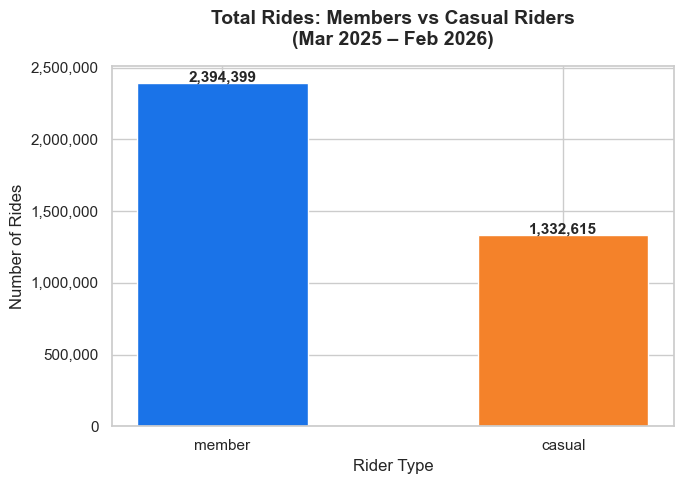

Chart 1 saved ✅


In [29]:
# Chart 1 -- Total Rides by Rider Type
# Data from SQL q1
ride_counts = pd.DataFrame({
    'rider_type': ['member', 'casual'],
    'total_rides': [2394399, 1332615]
})

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(ride_counts['rider_type'], ride_counts['total_rides'],
              color=[PALETTE[r] for r in ride_counts['rider_type']], width=0.5)

# Add value labels on top of bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
            f"{bar.get_height():,.0f}",
            ha='center', fontsize=11, fontweight='bold')

ax.set_title('Total Rides: Members vs Casual Riders\n(Mar 2025 – Feb 2026)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Rider Type', fontsize=12)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig(r'C:\Users\imtia\3.Hammad\projects\cyclistic\chart1_total_rides.png', dpi=150)
plt.show()
print('Chart 1 saved ✅')

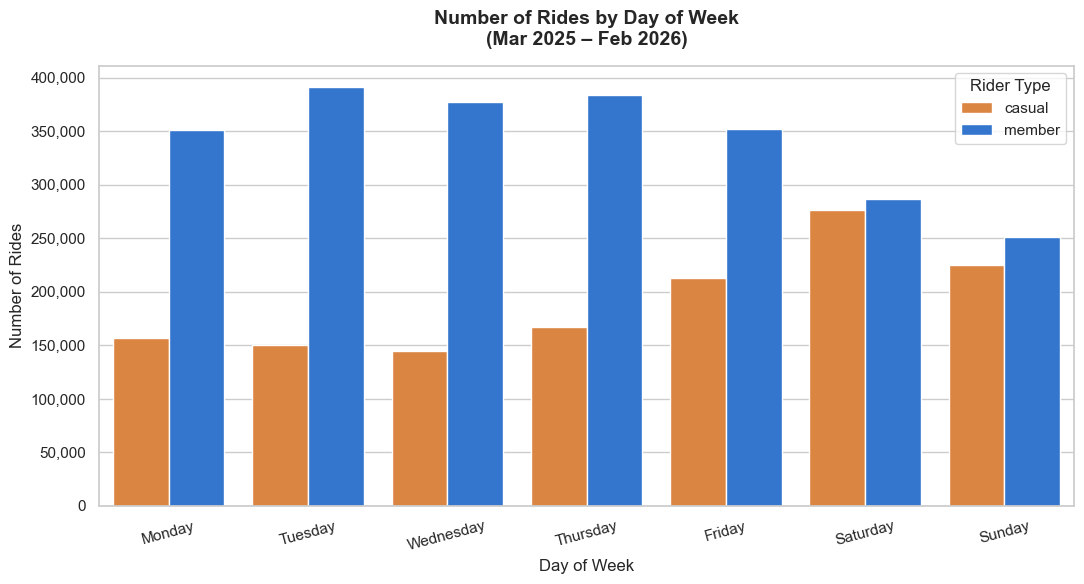

Chart 2 saved ✅


In [30]:
# Chart 2 -- Rides by Day of Week
# Data from SQL q3
rides_by_day = pd.DataFrame({
    'member_casual': ['casual']*7 + ['member']*7,
    'day_of_week': ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'] * 2,
    'total_rides': [156513, 150485, 144440, 166927, 212909, 276217, 225124,
                    351263, 391779, 377451, 384146, 352127, 286623, 251010]
})

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
rides_by_day['day_of_week'] = pd.Categorical(rides_by_day['day_of_week'],
                                              categories=day_order, ordered=True)
rides_by_day = rides_by_day.sort_values('day_of_week')

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=rides_by_day, x='day_of_week', y='total_rides',
            hue='member_casual', palette=PALETTE, ax=ax)

ax.set_title('Number of Rides by Day of Week\n(Mar 2025 – Feb 2026)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Rider Type')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(r'C:\Users\imtia\3.Hammad\projects\cyclistic\chart2_rides_by_day.png', dpi=150)
plt.show()
print('Chart 2 saved ✅')

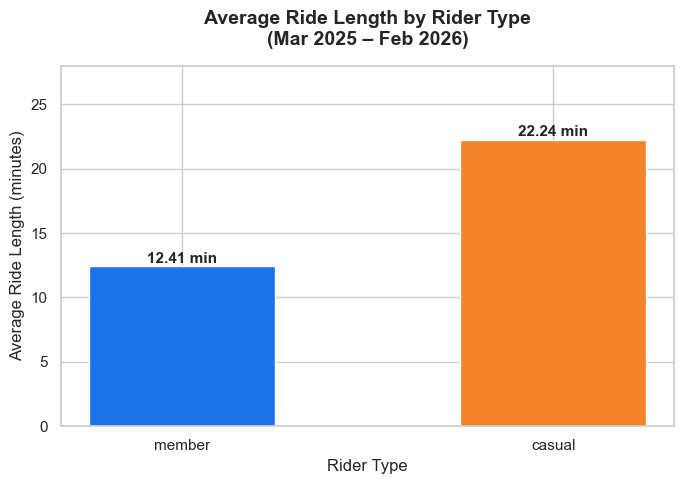

Chart 3 saved ✅


In [31]:
# Chart 3 -- Average Ride Length by Rider Type
# Data from SQL q2
avg_length = pd.DataFrame({
    'rider_type': ['member', 'casual'],
    'avg_ride_min': [12.41, 22.24]
})

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(avg_length['rider_type'], avg_length['avg_ride_min'],
              color=[PALETTE[r] for r in avg_length['rider_type']], width=0.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.2f} min",
            ha='center', fontsize=11, fontweight='bold')

ax.set_title('Average Ride Length by Rider Type\n(Mar 2025 – Feb 2026)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Rider Type', fontsize=12)
ax.set_ylabel('Average Ride Length (minutes)', fontsize=12)
ax.set_ylim(0, 28)
plt.tight_layout()
plt.savefig(r'C:\Users\imtia\3.Hammad\projects\cyclistic\chart3_avg_ride_length.png', dpi=150)
plt.show()
print('Chart 3 saved ✅')

In [32]:
print(f'Total rows: {len(df):,}')
print(f'Member counts:\n{df["member_casual"].value_counts()}')
q_check = pd.read_sql_query("SELECT COUNT(*) as rows FROM trips", conn)
print(q_check)
print(df.columns.tolist())

Total rows: 3,727,014
Member counts:
member_casual
member    2394399
casual    1332615
Name: count, dtype: int64
      rows
0  3727014
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual', 'ride_length', 'day_of_week', 'month', 'hour', 'season']


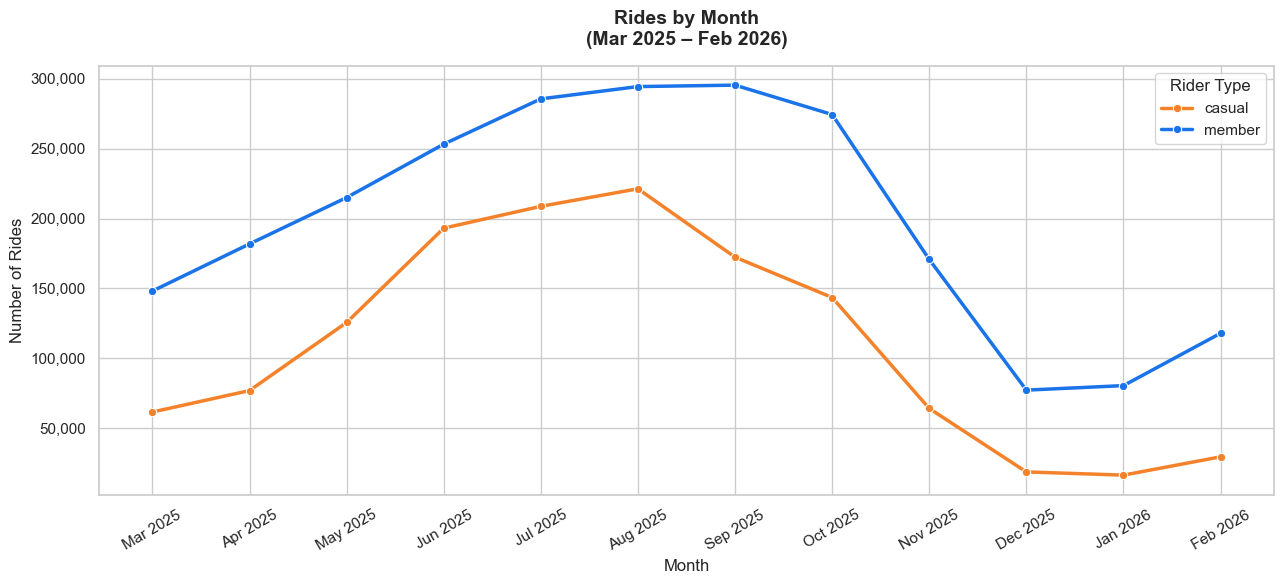

Chart 4 saved ✅


In [33]:
# Chart 4 -- Rides by Month
# Monthly ride counts by rider type
rides_by_month = pd.DataFrame({
    'member_casual': ['casual']*12 + ['member']*12,
    'month': ['Mar 2025','Apr 2025','May 2025','Jun 2025',
              'Jul 2025','Aug 2025','Sep 2025','Oct 2025',
              'Nov 2025','Dec 2025','Jan 2026','Feb 2026'] * 2,
    'total_rides': [
        # casual
        61666, 77008, 125683, 193110,
        208718, 221283, 172376, 143538,
        64198, 18840, 16552, 29636,
        # member
        148159, 181858, 215004, 253190,
        285543, 294343, 295372, 274347,
        170719, 77324, 80551, 117977
    ]
})

month_order = ['Mar 2025','Apr 2025','May 2025','Jun 2025',
               'Jul 2025','Aug 2025','Sep 2025','Oct 2025',
               'Nov 2025','Dec 2025','Jan 2026','Feb 2026']

rides_by_month['month'] = pd.Categorical(rides_by_month['month'],
                                          categories=month_order, ordered=True)
rides_by_month = rides_by_month.sort_values('month')

fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(data=rides_by_month, x='month', y='total_rides',
             hue='member_casual', palette=PALETTE,
             marker='o', linewidth=2.5, ax=ax)

ax.set_title('Rides by Month\n(Mar 2025 – Feb 2026)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Rider Type')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(r'C:\Users\imtia\3.Hammad\projects\cyclistic\chart4_rides_by_month.png', dpi=150)
plt.show()
print('Chart 4 saved ✅')

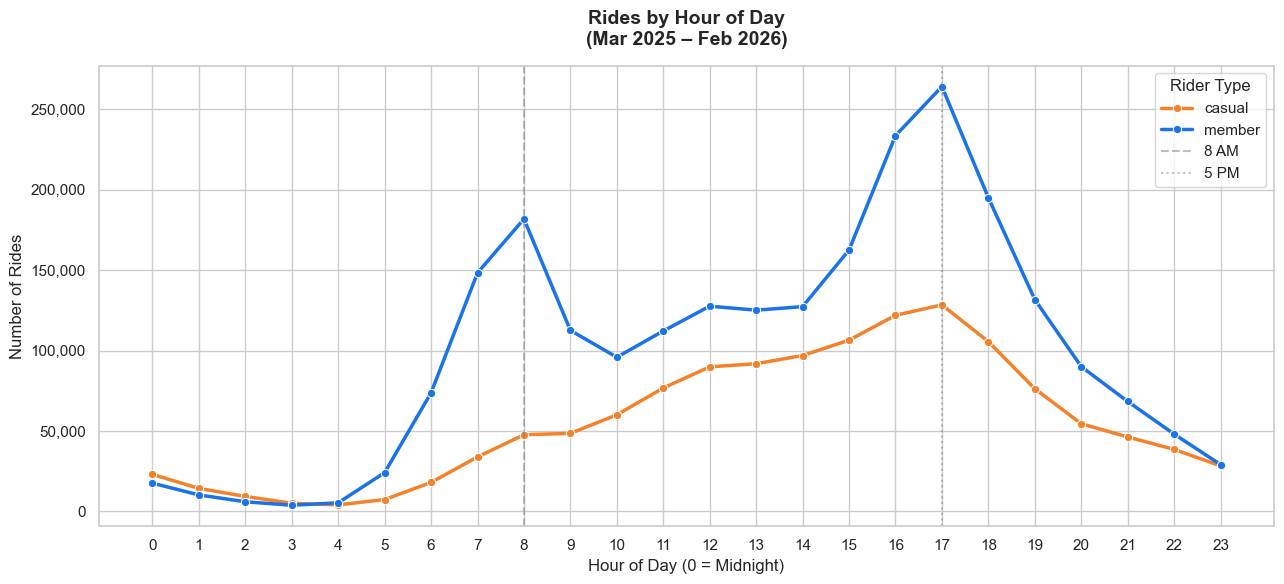

Chart 5 saved ✅


In [34]:
# Chart 5 -- Rides by Hour of Day
# Data from SQL q6
rides_by_hour = pd.DataFrame({
    'member_casual': ['casual']*24 + ['member']*24,
    'hour': list(range(24)) * 2,
    'total_rides': [
        # casual
        22997, 14273, 9288, 5013, 4019, 7327,
        17982, 33845, 47648, 48511, 60054, 76750,
        89886, 91820, 96935, 106486, 121945, 128429,
        105582, 76240, 54499, 46276, 38525, 28285,
        # member
        17526, 10221, 5940, 3792, 5305, 24087,
        73729, 148358, 181889, 112572, 95879, 112185,
        127626, 125140, 127352, 162575, 233714, 264240,
        195080, 131728, 90008, 68354, 48055, 29044
    ]
})

fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(data=rides_by_hour, x='hour', y='total_rides',
             hue='member_casual', palette=PALETTE,
             marker='o', linewidth=2.5, ax=ax)

# Highlight commute hours
ax.axvline(x=8, color='gray', linestyle='--', alpha=0.5, label='8 AM')
ax.axvline(x=17, color='gray', linestyle=':', alpha=0.5, label='5 PM')

ax.set_title('Rides by Hour of Day\n(Mar 2025 – Feb 2026)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day (0 = Midnight)', fontsize=12)
ax.set_ylabel('Number of Rides', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xticks(range(0, 24))
ax.legend(title='Rider Type')
plt.tight_layout()
plt.savefig(r'C:\Users\imtia\3.Hammad\projects\cyclistic\chart5_rides_by_hour.png', dpi=150)
plt.show()
print('Chart 5 saved ✅')

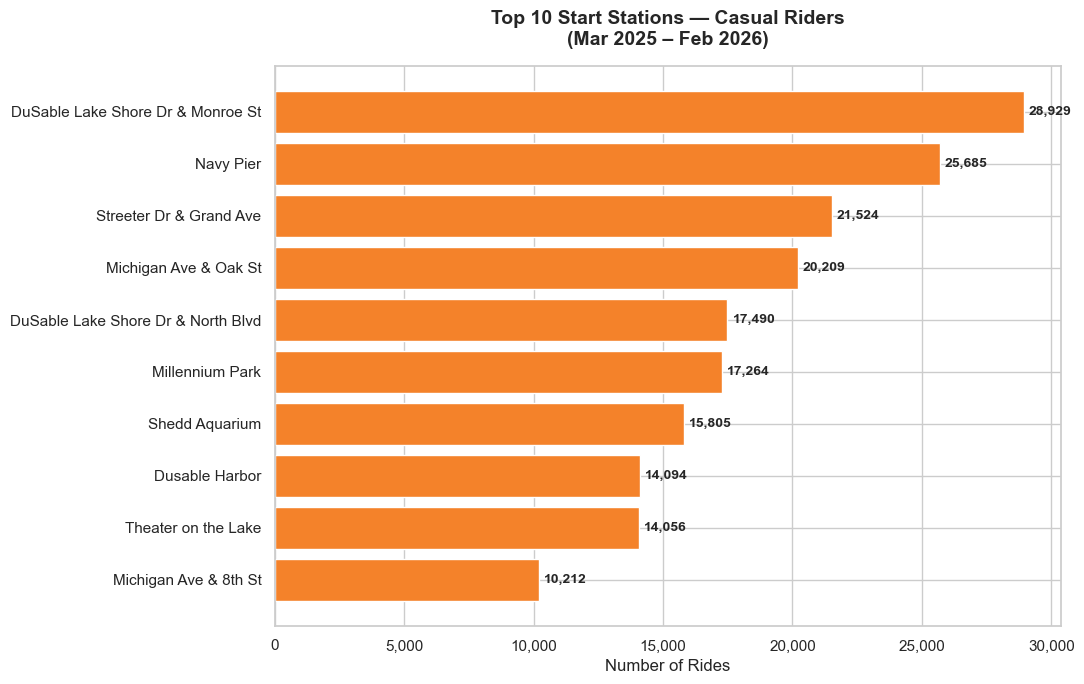

Chart 6 saved ✅


In [35]:
# chart 6 -- Top 10 Casual Rider Stations
# Data from SQL q5
top_stations = pd.DataFrame({
    'start_station_name': [
        'DuSable Lake Shore Dr & Monroe St',
        'Navy Pier',
        'Streeter Dr & Grand Ave',
        'Michigan Ave & Oak St',
        'DuSable Lake Shore Dr & North Blvd',
        'Millennium Park',
        'Shedd Aquarium',
        'Dusable Harbor',
        'Theater on the Lake',
        'Michigan Ave & 8th St'
    ],
    'total_rides': [28929, 25685, 21524, 20209, 17490,
                    17264, 15805, 14094, 14056, 10212]
})

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_stations['start_station_name'],
               top_stations['total_rides'],
               color=CASUAL_COLOR)

# Add value labels
for bar in bars:
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():,.0f}",
            va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Start Stations — Casual Riders\n(Mar 2025 – Feb 2026)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Rides', fontsize=12)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.invert_yaxis()  # highest bar on top
plt.tight_layout()
plt.savefig(r'C:\Users\imtia\3.Hammad\projects\cyclistic\chart6_top_stations.png', dpi=150)
plt.show()
print('Chart 6 saved ✅')

### Key Findings

| # | Finding | Data |
|---|---|---|
| 1 | Members ride significantly more | 64.2% vs 35.8% of all rides |
| 2 | Casuals ride nearly twice as long per trip | 22.24 min vs 12.41 min |
| 3 | Members peak weekdays, casuals peak weekends | Members: Tuesday, Casuals: Saturday |
| 4 | Casuals are highly seasonal | 47% of casual rides in summer, only 5% in winter |
| 5 | Members show clear commute pattern | Double spike at 8 AM and 5 PM |
| 6 | Casual hotspots are tourist landmarks | Navy Pier, Millennium Park, Shedd Aquarium |

---

<a id='phase6'></a>
## Phase 6: Act

### Final Conclusion

The data from **March 2025 to February 2026** clearly shows that members and casual riders use Cyclistic bikes for **fundamentally different purposes**.

- **Members** use Cyclistic as a commuting tool — riding on weekdays during rush hours, with short consistent trips year-round.
- **Casual riders** use Cyclistic for leisure — riding on weekends during afternoons, with longer trips concentrated in summer months at tourist destinations.

Casual riders are not simply infrequent members. They are a **different type of user** with different motivations, and the marketing strategy must speak directly to those motivations to drive conversion.

---

### Top 3 Recommendations

#### 1. Launch Weekend and Summer Membership Campaigns
Casual riders peak on **Saturdays (276,217 rides)** and in **summer (47% of all casual rides)**. A targeted discount campaign deployed via the Cyclistic app and social media during June–August would reach casual riders at exactly the moment they are most engaged with the product.

#### 2. Place Ads at Top Casual Rider Stations
The top 10 casual start stations are all tourist and leisure landmarks — Navy Pier, Millennium Park, Shedd Aquarium. Placing physical ads or QR codes at these docking stations with a simple cost comparison highlights the value of membership at the point of use.

#### 3. Show Personalised Cost Savings in the App
Casuals ride **79% longer per trip (22.24 min vs 12.41 min)**, meaning they spend significantly more per outing than members. A feature showing casual riders how much they would have saved with a membership — based on their own ride history — creates a direct personalised financial incentive to convert.

---

### Next Steps
- A/B test membership messaging at top casual stations
- Track conversion rates after campaign launch
- Collect opt-in demographic survey data to further segment casual riders
- Explore a weekend-only or summer membership tier to lower the barrier to entry

### Additional Data That Would Strengthen This Analysis
- Rider age, gender, and zip code via privacy-compliant survey
- Marketing channel performance data
- Pricing history correlated with casual ride volume
- Weather data to separate weather effects from seasonal trends

---
*End of Report — Cyclistic Bike-Share Case Study | March 2026*